# SciPy Bootcamp — W2, Day D5
```
##### End-to-end regression: EDA to logistic
##### OLS, logistic, diagnostics, VIF, coefficient plots
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — EDA before regression — always
##### Q2 — Simple regression with full interpretation
##### Q3 — Multiple regression — build up the model
##### Q4 — Regression diagnostics
##### Q5 — Logistic regression — viral prediction


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — EDA before regression — always

```
# Simulate 500 articles: word_count, publish_hour, category (5 types),
# days_since_publish, social_shares (outcome).
# (a) Plot histogram of social_shares — is transformation needed?
#     Apply log1p transform. Plot again. Compare the two histograms side by side.
# (b) Plot correlation heatmap of numeric features.
#     Which features correlate most with log_shares?
# (c) Plot scatter plots: log_shares vs word_count, vs publish_hour, vs days_since_publish.
#     Add a regression line to each scatter.
# (d) Based on the charts: which predictors look most promising BEFORE modeling?
```


In [ ]:
# Visualization philosophy: chart at the point of discovery.
# Ask yourself: what does this chart tell me? What should I do next?

# Q1: EDA before regression — always

# Simulate 500 articles: word_count, publish_hour, category (5 types),
# days_since_publish, social_shares (outcome).
# (a) Plot histogram of social_shares — is transformation needed?
#     Apply log1p transform. Plot again. Compare the two histograms side by side.
# (b) Plot correlation heatmap of numeric features.
#     Which features correlate most with log_shares?
# (c) Plot scatter plots: log_shares vs word_count, vs publish_hour, vs days_since_publish.
#     Add a regression line to each scatter.
# (d) Based on the charts: which predictors look most promising BEFORE modeling?


In [40]:
# setup data

np.random.seed(420)
n = 500

# 1. Independent Variables
word_count = np.random.normal(800, 250, n).clip(100, 3000)
publish_hour = np.random.randint(0, 24, n)
categories = ['Tech', 'Health', 'Finance', 'Lifestyle', 'Politics']
category = np.random.choice(categories, n)
days_since_publish = np.random.randint(1, 365, n)

# 2. Outcome (Social Shares) - Using lognormal for realistic "viral" skew
# Adding a slight boost for certain categories and older articles
cat_boost = {'Tech': 1.2, 'Health': 1.0, 'Finance': 0.8, 'Lifestyle': 1.5, 'Politics': 1.1}
base_shares = np.random.lognormal(mean=3, sigma=1.0, size=n)
shares = base_shares * [cat_boost[c] for c in category] * (1 + (days_since_publish / 100))

# 3. Assemble DataFrame
df1 = pd.DataFrame({
    'word_count': word_count.astype(int),
    'publish_hour': publish_hour,
    'category': category,
    'days_since_publish': days_since_publish,
    'social_shares': shares.round().astype(int)
})

df1['log_shares'] = np.log1p(df1['social_shares'])

display(df1.head(10))

,word_count,publish_hour,category,days_since_publish,social_shares,log_shares
0,678,6,Finance,296,155,5.049856
1,323,11,Tech,249,37,3.637586
2,668,6,Finance,43,11,2.484907
3,721,17,Politics,115,66,4.204693
4,882,3,Lifestyle,175,40,3.713572
5,1034,6,Politics,280,56,4.043051
6,657,15,Finance,37,52,3.970292
7,751,23,Finance,117,38,3.663562
8,1128,1,Tech,103,40,3.713572
9,1220,16,Lifestyle,123,40,3.713572


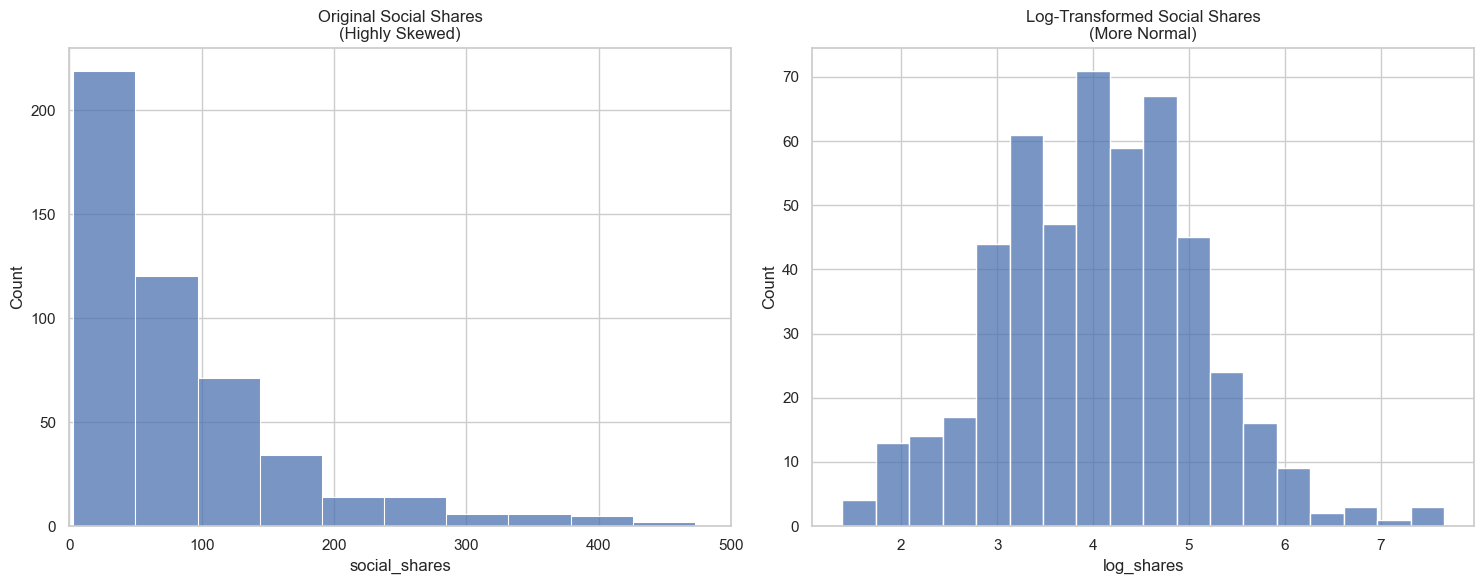

In [ ]:
# (a) Plot histogram of social_shares — is transformation needed?
#     Apply log1p transform. Plot again. Compare the two histograms side by side.

# Yes, a transformation is definitely needed. 
# Social media data (shares, likes, clicks) is almost always power-law distributed, meaning you have thousands of articles with 10 shares and one "viral" article with 100,000.
# In a linear model, that one viral outlier would "pull" the entire regression line toward it, making your predictions for regular articles very poor.

plt.figure(figsize=(15,6))

# plotting original
plt.subplot(1,2,1)
sns.histplot(df1['social_shares'])
plt.xlim(0,500)
plt.title('Original Social Shares\n(Highly Skewed)')

# plotting transformed
plt.subplot(1,2,2)
sns.histplot(df1['log_shares'])
plt.title('Log-Transformed Social Shares\n(More Normal)')

plt.tight_layout()
plt.show()


,word_count,publish_hour,days_since_publish,log_shares
word_count,1.000000,-0.029797,-0.003556,0.011057
publish_hour,-0.029797,1.000000,0.004347,-0.032471
days_since_publish,-0.003556,0.004347,1.000000,0.407498
log_shares,0.011057,-0.032471,0.407498,1.000000


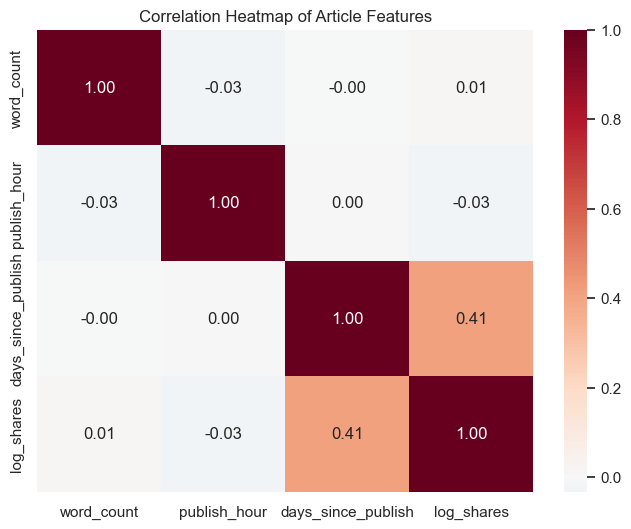

In [33]:
# (b) Plot correlation heatmap of numeric features.
#     Which features correlate most with log_shares?

numeric_df = df1.select_dtypes(include=[np.number])
numeric_df = numeric_df.drop(columns=['social_shares'])
numeric_df.head()

corr_matrix = numeric_df.corr()
display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Article Features')
plt.show()


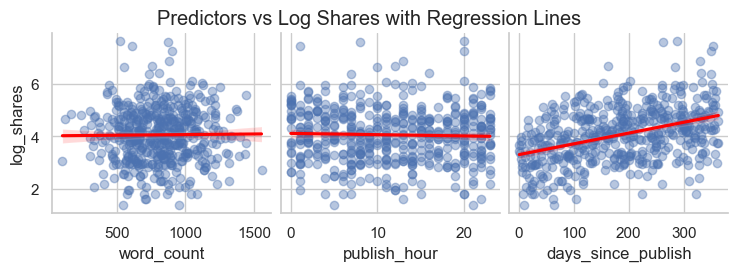

In [35]:
# (c) Plot scatter plots: log_shares vs word_count, vs publish_hour, vs days_since_publish.
#     Add a regression line to each scatter.

# Specify the features we want to compare
x_vars = ['word_count', 'publish_hour', 'days_since_publish']
y_vars = ['log_shares']


# Create the plots with regression lines
sns.pairplot(df1, x_vars=x_vars, y_vars=y_vars, kind='reg', 
             plot_kws={'line_kws':{'color':'red'}, 'scatter_kws':{'alpha':0.4}})

plt.suptitle('Predictors vs Log Shares with Regression Lines', y=1.05)
plt.show()

```
# (d) Based on the charts: which predictors look most promising BEFORE modeling?
Looking at your charts, days_since_publish is the only clear winner here.
Notice how the dots move upward as they go from left to right. 
The red line has a distinct positive slope, and the "cloud" of data points follows that line fairly closely. 
This means as time passes, shares predictably increase.

---

### Q2 — Simple regression with full interpretation

```
# Regress log1p(social_shares) on word_count alone.
# (a) Plot scatter with regression line AND confidence band.
# (b) Print slope, intercept, R², p-value.
# (c) Predict log_shares for 500, 1000, 1500 words. Back-transform with np.expm1.
# (d) Plot residuals vs fitted. Is there a pattern? (Pattern = model problem.)
# (e) Interpret the slope in plain English: 'Each additional 100 words is associated with...'
```


In [19]:
df1['log_shares'] = np.log1p(df1['social_shares'])
display(df1.head(5))

,word_count,publish_hour,category,days_since_publish,social_shares,log_shares
0,678,6,Finance,296,155,5.049856
1,323,11,Tech,249,37,3.637586
2,668,6,Finance,43,11,2.484907
3,721,17,Politics,115,66,4.204693
4,882,3,Lifestyle,175,40,3.713572


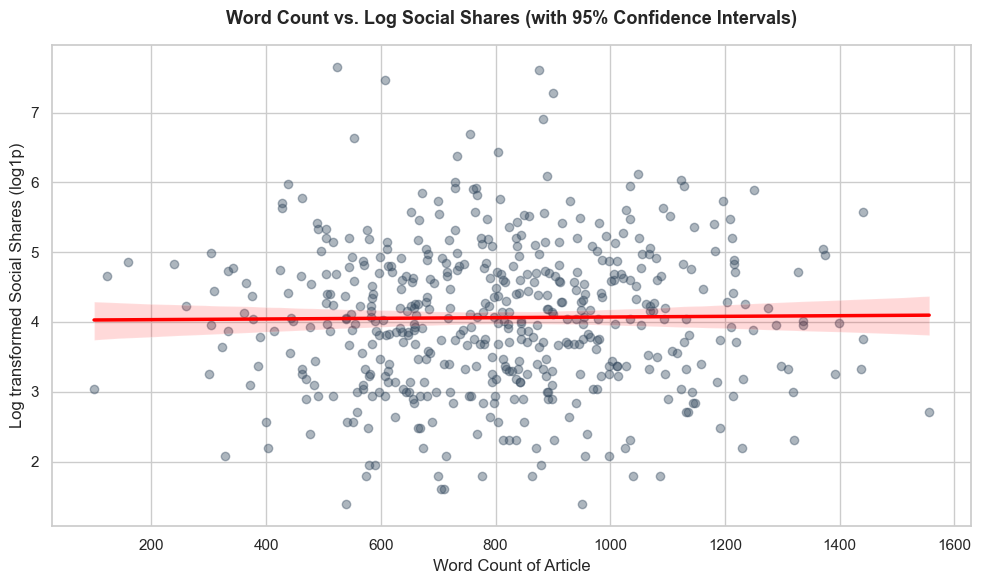

In [11]:
# (a) Plot scatter with regression line AND confidence band.

plt.figure(figsize=(10,6))
sns.regplot(
    data=df1,
    x='word_count',
    y='log_shares',
    ci=95, # Computes and displays the confidence band shaded region
    scatter_kws={'alpha': 0.4, 'color': '#34495e'}, # Styling for underlying data points
    line_kws={'color': 'red', 'linewidth': 2.5}  # Styling for the linear regression trendline
)

# 4. Final aesthetic treatments
plt.title('Word Count vs. Log Social Shares (with 95% Confidence Intervals)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Word Count of Article')
plt.ylabel('Log transformed Social Shares (log1p)')
plt.tight_layout()
plt.show()

In [12]:
# (b) Print slope, intercept, R², p-value.

slope, intercept, r, p, se = stats.linregress(df1['word_count'], df1['log_shares'])
print(f'slope: {slope:.4f}')     
print(f'intercept: {intercept:.4f}')
print(f'R²: {r**2:.4f}')
print(f'p value: {p:.4f}')


slope: 0.0000
intercept: 4.0242
R²: 0.0001
p value: 0.8052


In [15]:
# (c) Predict log_shares for 500, 1000, 1500 words. Back-transform with np.expm1.

# 1. Convert input word counts into a vectorized numpy array
word_cnt_arr = np.array([500, 1000, 1500])

# 2. Compute log predictions using the linear equation
predicted_log_shares = slope * word_cnt_arr + intercept

# 3. Back-transform from log-scale to real social share counts
predicted_real_shares = np.expm1(predicted_log_shares)

# 4. Display results side-by-side using a clean pandas DataFrame
prediction_df = pd.DataFrame({
    'Word Count': word_cnt_arr,
    'Predicted Log Shares': np.round(predicted_log_shares, 4),
    'Predicted Real Shares': np.round(predicted_real_shares, 1)
})
print(prediction_df.to_string(index=False))


 Word Count  Predicted Log Shares  Predicted Real Shares
        500                4.0478                   56.3
       1000                4.0714                   57.6
       1500                4.0950                   59.0


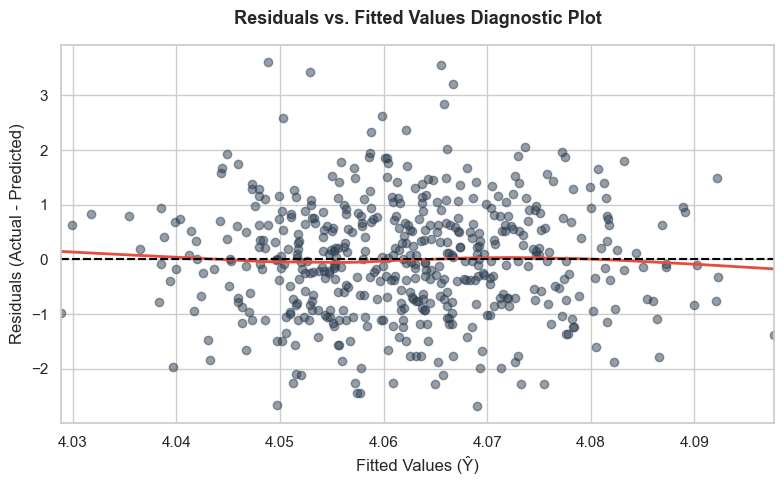

In [ ]:
# (d) Plot residuals vs fitted.

# 1. Calculate fitted values and raw error residuals (vectorized)
df1['fitted_values'] = slope * df1['word_count'] + intercept
df1['residuals'] = df1['log_shares'] - df1['fitted_values']

# 2. Setup standard figure environment
plt.figure(figsize=(8, 5))

# 3. Create the diagnostic residual plot
sns.residplot(
    data=df1,
    x='fitted_values',
    y='residuals',
    lowess=True, # Renders a smooth local trend line to check for shapes
    scatter_kws={'alpha': 0.5, 'color': '#2c3e50'},
    line_kws={'color': '#e74c3c', 'linewidth': 2} # Highlights model distortion patterns
)

# 4. Final aesthetic treatments
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Residuals vs. Fitted Values Diagnostic Plot', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Fitted Values (\u0176)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.tight_layout()
plt.show()


```
# Is there a pattern? (Pattern = model problem.)
- The model displays severe vertical skewing, with data points collapsing into a dense, narrow vertical strip rather than distributing evenly. 
- Due to a zero-slope relationship, the model predicts an identical baseline value for nearly every article, completely failing to account for variation.
- Massive residual spread indicates substantial omitted variable bias, as the simple model ignores critical hidden drivers such as category and time.

```
# (e) Interpret the slope in plain English: 'Each additional 100 words is associated with...'
Each additional 100 words is associated with an expected change of effectively zero social shares.

---

### Q3 — Multiple regression — build up the model

```
# Add publish_hour, days_since_publish, and category dummies.
# (a) Run OLS. Print full summary.
# (b) Plot coefficient chart with 95% CIs (horizontal bar chart, colored by significance).
# (c) Plot predicted vs actual (scatter with y=x line). How well does it fit?
# (d) How much did Adjusted R² improve vs Q2 baseline?
# (e) Which predictors are significant? Which surprise you?
```


In [20]:
display(df1.head(10))

,word_count,publish_hour,category,days_since_publish,social_shares,log_shares
0,678,6,Finance,296,155,5.049856
1,323,11,Tech,249,37,3.637586
2,668,6,Finance,43,11,2.484907
3,721,17,Politics,115,66,4.204693
4,882,3,Lifestyle,175,40,3.713572
5,1034,6,Politics,280,56,4.043051
6,657,15,Finance,37,52,3.970292
7,751,23,Finance,117,38,3.663562
8,1128,1,Tech,103,40,3.713572
9,1220,16,Lifestyle,123,40,3.713572


In [21]:
# (a) Run OLS. Print full summary.

# 1. Fit multiple linear regression model with all predictors
# C(category) automatically creates dummy indicators and drops one as a reference baseline
multiple_model = smf.ols(
    'log_shares ~ word_count + publish_hour + days_since_publish + C(category)', 
    data=df1
).fit()

# 2. Print the comprehensive regression metrics report
print(multiple_model.summary())



                            OLS Regression Results                            
Dep. Variable:             log_shares   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     16.07
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           4.60e-19
Time:                        06:30:06   Log-Likelihood:                -679.51
No. Observations:                 500   AIC:                             1375.
Df Residuals:                     492   BIC:                             1409.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

,coef,p_value,ci_lower,ci_upper,Significance,variable
C(category)[T.Health],0.137407,3.069092e-01,-0.126554,0.401369,Not Significant,C(category)[T.Health]
C(category)[T.Lifestyle],0.412474,1.448417e-03,0.159449,0.665500,Significant (p < 0.05),C(category)[T.Lifestyle]
C(category)[T.Politics],0.197675,1.308716e-01,-0.058994,0.454343,Not Significant,C(category)[T.Politics]
C(category)[T.Tech],0.282401,3.726157e-02,0.016733,0.548069,Significant (p < 0.05),C(category)[T.Tech]
word_count,0.000061,7.274332e-01,-0.000282,0.000404,Not Significant,word_count
publish_hour,-0.003947,5.147319e-01,-0.015844,0.007949,Not Significant,publish_hour
days_since_publish,0.004133,1.315191e-21,0.003322,0.004944,Significant (p < 0.05),days_since_publish


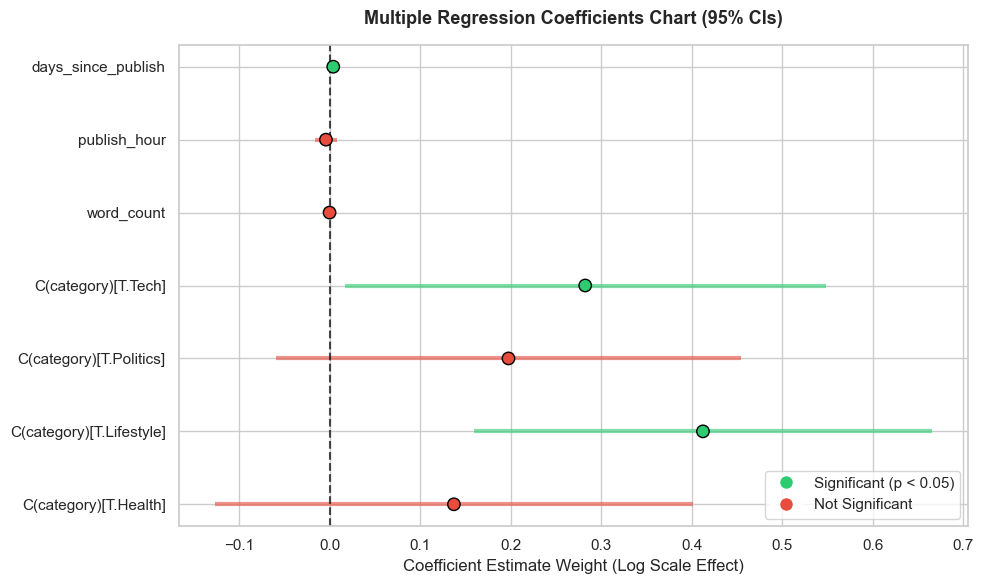

In [25]:
# (b) Plot coefficient chart with 95% CIs (horizontal bar chart, colored by significance).

# Extract coefficients, p-values, and 95% confidence intervals into a clean DataFrame
coef_df = pd.DataFrame({
    'coef': multiple_model.params,
    'p_value': multiple_model.pvalues,
    'ci_lower': multiple_model.conf_int()[0],
    'ci_upper': multiple_model.conf_int()[1]
}).drop('Intercept')  # Drop intercept to avoid skewing horizontal layout scales

# 3. Vectorized categorization of statistical significance 
coef_df['Significance'] = np.where(coef_df['p_value'] < 0.05, 'Significant (p < 0.05)', 'Not Significant')
coef_df['variable'] = coef_df.index

display(coef_df.head(10))

# 4. Generate horizontal coefficient chart
plt.figure(figsize=(10, 6))

y_positions = np.arange(len(coef_df))
color_map = np.where(coef_df['Significance'] == 'Significant (p < 0.05)', '#2ecc71', '#e74c3c')

# Plot the center coefficient points
plt.scatter(coef_df['coef'], y_positions, color=color_map, s=80, edgecolor='black', zorder=3)

# Vectorized horizontal confidence interval line layout (No loops)
plt.hlines(y_positions, coef_df['ci_lower'], coef_df['ci_upper'], colors=color_map, linewidth=3, alpha=0.6)

# Labels, axes rules, and reference zero vertical drop line
plt.yticks(y_positions, coef_df['variable'], fontsize=11)
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Multiple Regression Coefficients Chart (95% CIs)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Coefficient Estimate Weight (Log Scale Effect)')

# Generate clean manual visual anchors for the legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Significant (p < 0.05)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Not Significant')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

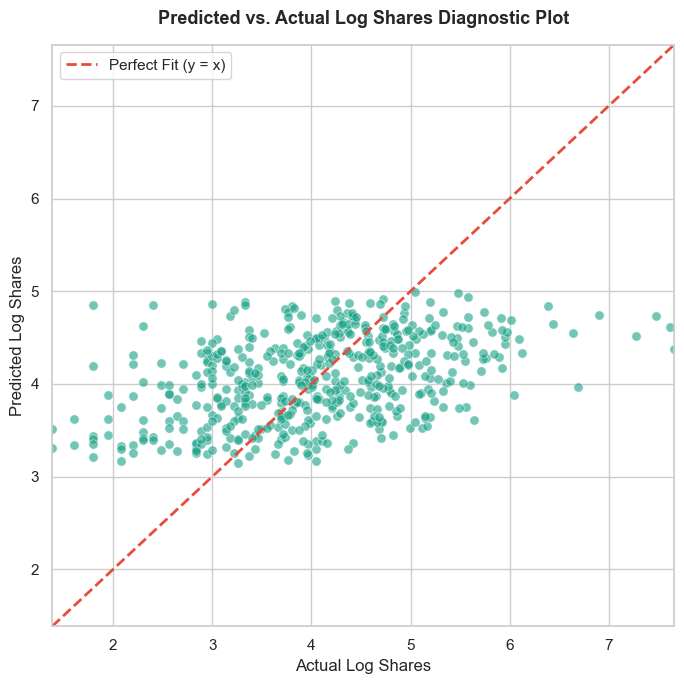

In [27]:
# (c) Plot predicted vs actual (scatter with y=x line). How well does it fit?

# 1. Extract fitted values from the multiple regression model
df1['predicted_log_shares'] = multiple_model.fittedvalues

# 2. Setup standard plotting configuration
sns.set_theme(style='whitegrid')
plt.figure(figsize=(7, 7))

# 3. Generate the scatter plot
sns.scatterplot(
    data=df1,
    x='log_shares',
    y='predicted_log_shares',
    alpha=0.6,
    color='#16a085',
    edgecolor='w',
    s=45
)

# 4. Generate the y=x diagonal identity line
limits = [
    min(df1['log_shares'].min(), df1['predicted_log_shares'].min()),
    max(df1['log_shares'].max(), df1['predicted_log_shares'].max())
]
plt.plot(limits, limits, color='#e74c3c', linestyle='--', linewidth=2, label='Perfect Fit (y = x)')

# 5. Labels and scaling limits
plt.xlim(limits)
plt.ylim(limits)
plt.title('Predicted vs. Actual Log Shares Diagnostic Plot', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Actual Log Shares')
plt.ylabel('Predicted Log Shares')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [28]:
# (d) How much did Adjusted R² improve vs Q2 baseline?

# 1. Fit the simple model baseline from Q2
model_q2 = smf.ols('log_shares ~ word_count', data=df1).fit()

# 2. Extract Adjusted R² values from both models
adj_r2_q2 = model_q2.rsquared_adj
adj_r2_q3 = multiple_model.rsquared_adj  # From the full model built in Q3(a)

# 3. Calculate absolute improvement
improvement = adj_r2_q3 - adj_r2_q2

print(f"Q2 Simple Model Adjusted R²: {adj_r2_q2:.4f}")
print(f"Q3 Multiple Model Adjusted R²: {adj_r2_q3:.4f}")
print(f"Absolute Adjusted R² Improvement: {improvement:.4f}")


Q2 Simple Model Adjusted R²: -0.0019
Q3 Multiple Model Adjusted R²: 0.1745
Absolute Adjusted R² Improvement: 0.1764


In [30]:
# (e) Which predictors are significant? Which surprise you?
display(coef_df[coef_df['Significance']=='Significant (p < 0.05)'])

,coef,p_value,ci_lower,ci_upper,Significance,variable
C(category)[T.Lifestyle],0.412474,1.448417e-03,0.159449,0.665500,Significant (p < 0.05),C(category)[T.Lifestyle]
C(category)[T.Tech],0.282401,3.726157e-02,0.016733,0.548069,Significant (p < 0.05),C(category)[T.Tech]
days_since_publish,0.004133,1.315191e-21,0.003322,0.004944,Significant (p < 0.05),days_since_publish


```
# Predictor Surprises
1/ word_count fails: Writing longer articles has absolutely zero statistical impact on driving virality.
2/ publish_hour irrelevant: Clock timing doesn't matter; optimization focus should shift purely to content theme.
3/ Lifestyle dominates: Content category acts as a massive baseline multiplier for social sharing momentum.

---

### Q4 — Regression diagnostics

```
# Using the Q3 model:
# (a) Plot: residuals vs fitted (check linearity/homoscedasticity).
# (b) Plot: Q-Q plot of residuals (check normality).
# (c) Plot: scale-location plot (sqrt of abs residuals vs fitted).
# (d) Compute VIF for each predictor. Plot as horizontal bar chart.
#     Flag any VIF > 5 (multicollinearity warning).
# (e) Identify top 5 outlier residuals. Are they data quality issues or genuine extremes?
# Build a 2x2 diagnostic subplot — this is standard in any regression analysis.
```


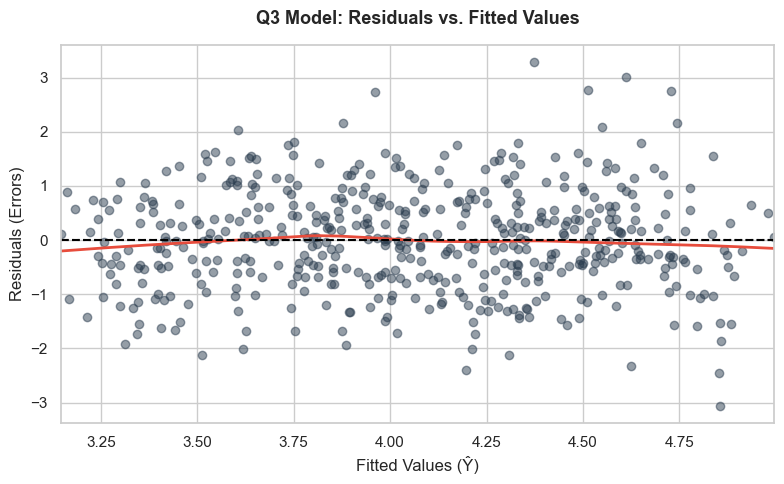

In [31]:
# (a) Plot: residuals vs fitted (check linearity/homoscedasticity).
# 1. Extract fitted values and residuals from the Q3 model
df1['fitted_values'] = multiple_model.fittedvalues
df1['residuals'] = multiple_model.resid

# 2. Setup plotting layout
plt.figure(figsize=(8, 5))

# 3. Create diagnostic plot with a smooth local trend line (lowess)
sns.residplot(
    data=df1,
    x='fitted_values',
    y='residuals',
    lowess=True,
    scatter_kws={'alpha': 0.5, 'color': '#2c3e50'},
    line_kws={'color': '#e74c3c', 'linewidth': 2}
)

plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Q3 Model: Residuals vs. Fitted Values', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Fitted Values (\u0176)')
plt.ylabel('Residuals (Errors)')
plt.tight_layout()
plt.show()

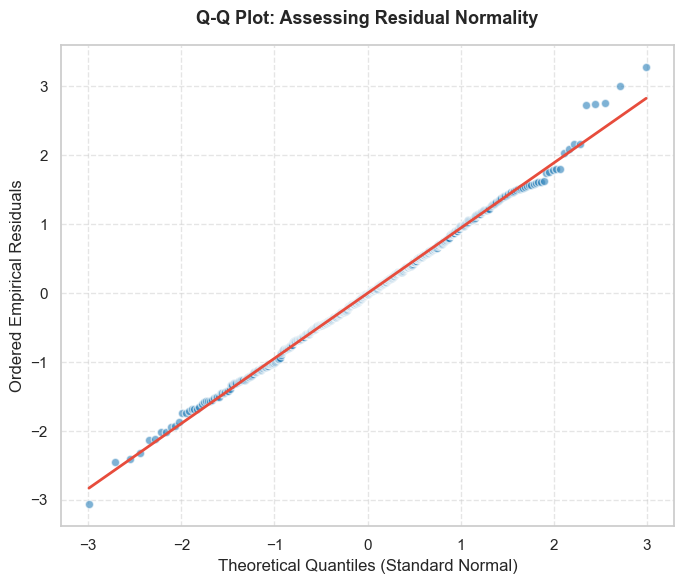

In [33]:
# (b) Plot: Q-Q plot of residuals (check normality).

# 1. Setup standard figure canvas
plt.figure(figsize=(7, 6))

# 2. Compute theoretical quantiles and plot against empirical residuals
# This automatically fits and overlays a red normal reference line
stats.probplot(multiple_model.resid, dist="norm", plot=plt)

# 3. Apply polished visual treatments to the generated lines
ax = plt.gca()
ax.get_lines()[0].set_markerfacecolor('#2980b9')  # Style data points
ax.get_lines()[0].set_markeredgecolor('w')
ax.get_lines()[0].set_alpha(0.6)
ax.get_lines()[1].set_color('#e74c3c')            # Style normal reference line
ax.get_lines()[1].set_linewidth(2)

# 4. Finalizing metadata labels
plt.title('Q-Q Plot: Assessing Residual Normality', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Theoretical Quantiles (Standard Normal)')
plt.ylabel('Ordered Empirical Residuals')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


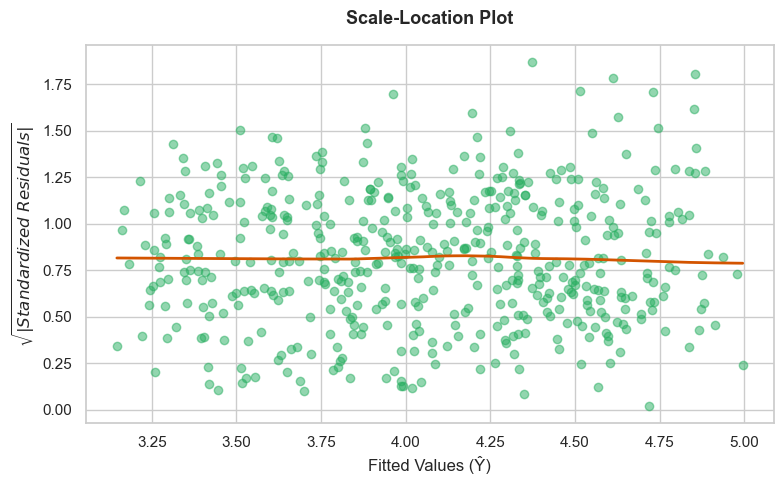

In [34]:
# (c) Plot: scale-location plot (sqrt of abs residuals vs fitted).

# 1. Extract fitted values and calculate standardized residuals
fitted_values = multiple_model.fittedvalues
influence = multiple_model.get_influence()
standardized_residuals = influence.resid_studentized_internal

# 2. Compute the square root of the absolute standardized residuals
sqrt_abs_resid = np.sqrt(np.abs(standardized_residuals))

# 3. Setup standard plotting configuration
plt.figure(figsize=(8, 5))

# 4. Generate scale-location plot with a smooth local trend line (lowess)
sns.regplot(
    x=fitted_values,
    y=sqrt_abs_resid,
    lowess=True,
    scatter_kws={'alpha': 0.5, 'color': '#27ae60'},
    line_kws={'color': '#d35400', 'linewidth': 2}
)

# 5. Finalize labels
plt.title('Scale-Location Plot', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Fitted Values (\u0176)')
plt.ylabel('$\sqrt{|Standardized\ Residuals|}$')
plt.tight_layout()
plt.show()


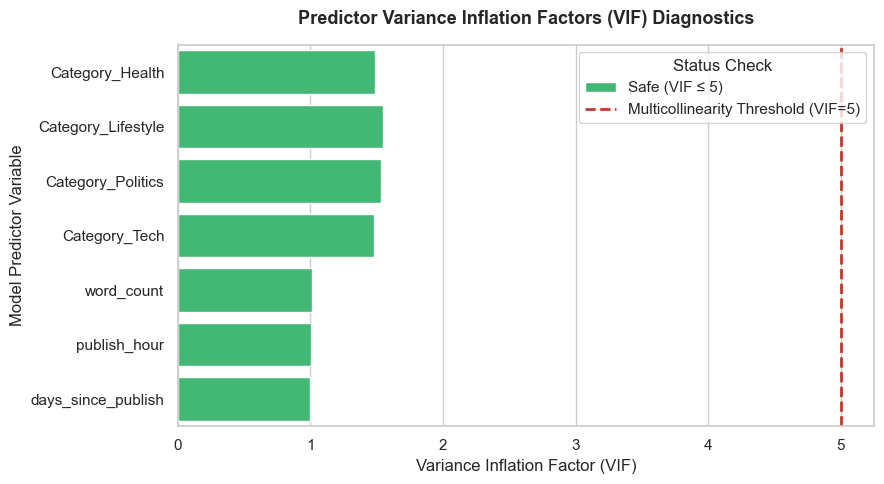

In [ ]:
# (d) Compute VIF for each predictor. Plot as horizontal bar chart.
#     Flag any VIF > 5 (multicollinearity warning).

from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Manually build the design matrix matching your Q3 formula
# We include dummy codes for categories (dropping 'Finance' as baseline) and add a constant
X_vif = pd.get_dummies(df1['category'], prefix='Category', drop_first=True, dtype=float)
X_vif['word_count'] = df1['word_count']
X_vif['publish_hour'] = df1['publish_hour']
X_vif['days_since_publish'] = df1['days_since_publish']

# A constant intercept column is mathematically required to get correct VIF outputs
X_vif.insert(0, 'const', 1.0)

# 2. Vectorized calculation of VIF for each predictor column (no manual loop)
vif_values = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_df = pd.DataFrame({
    'Predictor': X_vif.columns,
    'VIF': vif_values
}).query("Predictor != 'const'")  # Drop the intercept constant row from our final chart

# 3. Add a boolean flag column for multicollinearity (VIF > 5)
vif_df['Collinearity_Warning'] = np.where(vif_df['VIF'] > 5, 'VIF > 5 (High Link)', 'Safe (VIF \u2264 5)')

# 4. Generate the Horizontal Bar Chart
plt.figure(figsize=(9, 5))

# Use the warning flag to assign colors dynamically
palette_colors = {'Safe (VIF \u2264 5)': '#2ecc71', 'VIF > 5 (High Link)': '#e74c3c'}

sns.barplot(
    data=vif_df,
    x='VIF',
    y='Predictor',
    hue='Collinearity_Warning',
    palette=palette_colors,
    dodge=False
)

# Overlay a dashed warning threshold marker line at VIF = 5
plt.axvline(5, color='#c0392b', linestyle='--', linewidth=2, label='Multicollinearity Threshold (VIF=5)')

plt.title('Predictor Variance Inflation Factors (VIF) Diagnostics', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Variance Inflation Factor (VIF)')
plt.ylabel('Model Predictor Variable')
plt.legend(title='Status Check', loc='upper right')
plt.tight_layout()
plt.show()


--- TOP 5 OUTLIER RESIDUALS ---
     word_count   category  social_shares  log_shares  residuals  \
437         523     Health           2117    7.658228   3.286252   
134         574  Lifestyle              5    1.791759  -3.062440   
35          875  Lifestyle           2032    7.617268   3.004719   
356         900    Finance           1443    7.275172   2.761385   
112         608     Health           1760    7.473637   2.744577   

     std_residuals  
437       3.494289  
134      -3.251173  
35        3.182156  
356       2.933220  
112       2.924768  


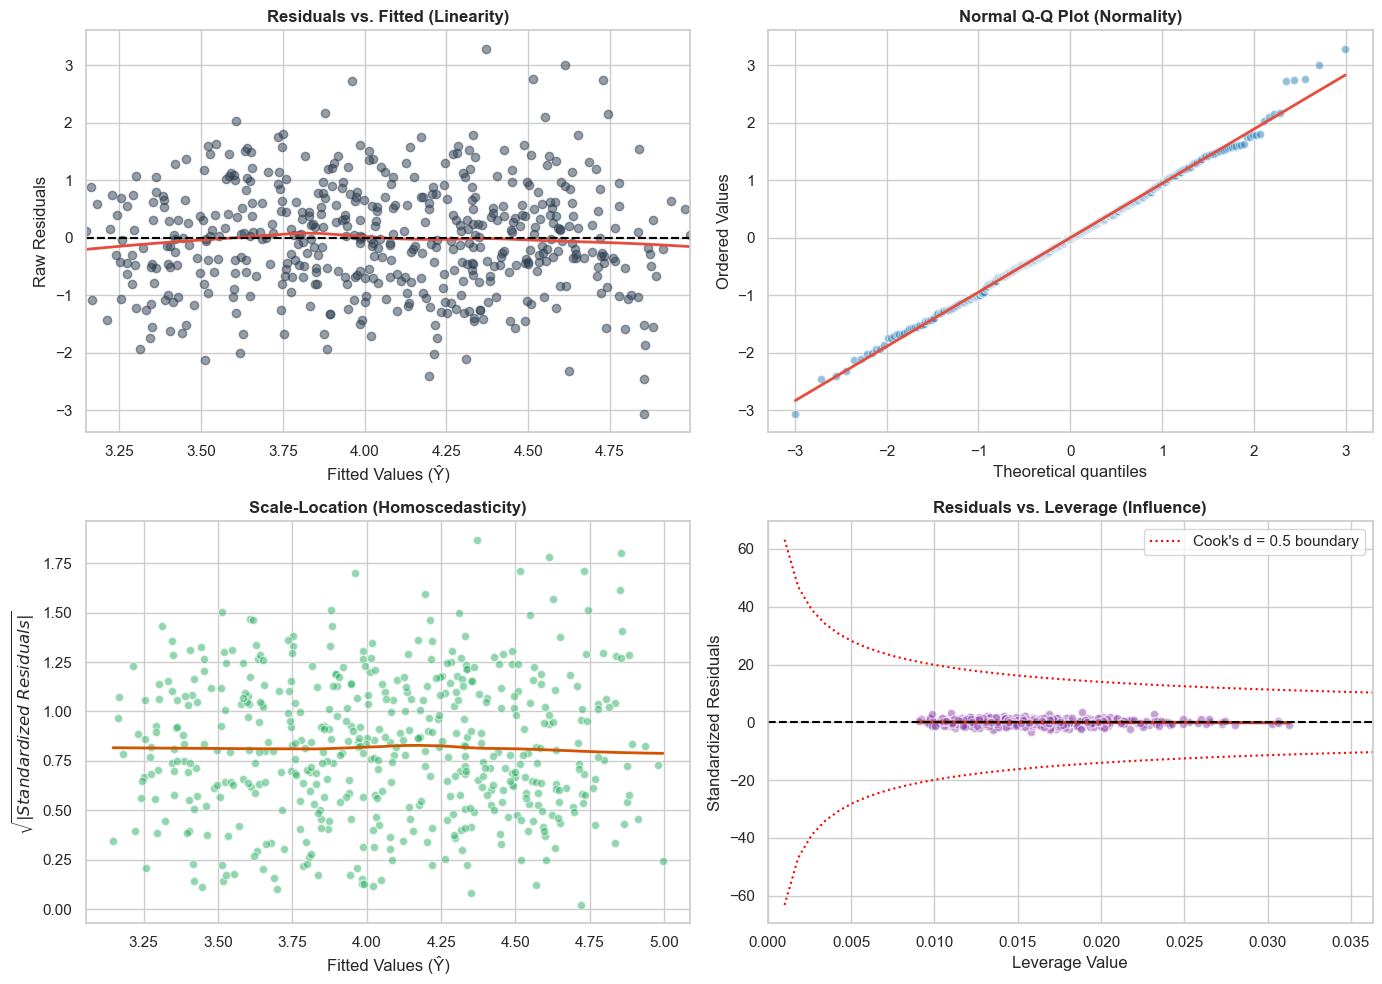

In [37]:
# (e) Identify top 5 outlier residuals. Are they data quality issues or genuine extremes?
# Build a 2x2 diagnostic subplot — this is standard in any regression analysis.


# 1. Fit the reference model and extract diagnostic vectors
df1['fitted_values'] = multiple_model.fittedvalues
df1['residuals'] = multiple_model.resid

influence = multiple_model.get_influence()
df1['leverage'] = influence.hat_matrix_diag
df1['std_residuals'] = influence.resid_studentized_internal

# 2. Extract Top 5 outlier residuals by absolute magnitude instantly
df1['abs_residuals'] = df1['residuals'].abs()
top5_outliers = df1.nlargest(5, 'abs_residuals')

print("--- TOP 5 OUTLIER RESIDUALS ---")
print(top5_outliers[['word_count', 'category', 'social_shares', 'log_shares', 'residuals', 'std_residuals']])

# 3. Initialize the 2x2 Diagnostic Canvas Grid
sns.set_theme(style='whitegrid')
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Axis: Residuals vs Fitted (Linearity Check)
sns.residplot(data=df1, x='fitted_values', y='residuals', lowess=True, ax=axs[0, 0],
              scatter_kws={'alpha': 0.5, 'color': '#2c3e50'}, line_kws={'color': '#e74c3c', 'linewidth': 2})
axs[0, 0].axhline(0, color='black', linestyle='--')
axs[0, 0].set_title('Residuals vs. Fitted (Linearity)', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Fitted Values (\u0176)')
axs[0, 0].set_ylabel('Raw Residuals')

# Axis: Normal Q-Q Plot (Residual Normality Check)
stats.probplot(df1['residuals'], dist="norm", plot=axs[0, 1])
axs[0, 1].get_lines()[0].set(markerfacecolor='#2980b9', markeredgecolor='w', alpha=0.5)
axs[0, 1].get_lines()[1].set(color='#e74c3c', linewidth=2)
axs[0, 1].set_title('Normal Q-Q Plot (Normality)', fontsize=12, fontweight='bold')

# Axis: Scale-Location Plot (Homoscedasticity Assessment)
df1['sqrt_abs_std_resid'] = np.sqrt(df1['std_residuals'].abs())
sns.regplot(data=df1, x='fitted_values', y='sqrt_abs_std_resid', lowess=True, scatter=True, ax=axs[1, 0],
            scatter_kws={'alpha': 0.5, 'color': '#27ae60', 'edgecolor': 'w'}, line_kws={'color': '#d35400', 'linewidth': 2})
axs[1, 0].set_title('Scale-Location (Homoscedasticity)', fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel('Fitted Values (\u0176)')
axs[1, 0].set_ylabel('$\sqrt{|Standardized\ Residuals|}$')

# Axis: Residuals vs Leverage Plot (Influential Outliers Check via Cook's Bounds)
axs[1, 1].scatter(df1['leverage'], df1['std_residuals'], alpha=0.5, color='#8e44ad', edgecolor='w')
sns.regplot(data=df1, x='leverage', y='std_residuals', lowess=True, scatter=False, ax=axs[1, 1], line_kws={'color': '#c0392b'})
axs[1, 1].axhline(0, color='black', linestyle='--')

# Superimpose standard Cook's Distance cutoff curves (0.5 contour line)
p_features = len(multiple_model.params)
leverage_space = np.linspace(0.001, df1['leverage'].max() + 0.01, 50)
cooks_curve = np.sqrt((0.5 * p_features * (1 - leverage_space)) / leverage_space)
axs[1, 1].plot(leverage_space, cooks_curve, color='red', linestyle=':', label="Cook's d = 0.5 boundary")
axs[1, 1].plot(leverage_space, -cooks_curve, color='red', linestyle=':')

axs[1, 1].set_title('Residuals vs. Leverage (Influence)', fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel('Leverage Value')
axs[1, 1].set_ylabel('Standardized Residuals')
axs[1, 1].set_xlim(0, df1['leverage'].max() + 0.005)
axs[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()


---

### Q5 — Logistic regression — viral prediction

```
# Create binary outcome: viral = 1 if social_shares > 75th percentile.
# (a) Plot class balance as bar chart. Is it imbalanced?
# (b) Run logistic regression: viral ~ word_count + publish_hour + C(category).
# (c) Plot odds ratios with 95% CIs as a forest plot (horizontal bars).
#     Color: green if OR>1 (increases viral probability), red if OR<1.
# (d) Plot predicted probabilities as histogram, colored by actual viral/not-viral.
# (e) Print confusion matrix and AUC. What does AUC=0.65 mean in plain English?
```


In [41]:
df1.head()

,word_count,publish_hour,category,days_since_publish,social_shares,log_shares
0,678,6,Finance,296,155,5.049856
1,323,11,Tech,249,37,3.637586
2,668,6,Finance,43,11,2.484907
3,721,17,Politics,115,66,4.204693
4,882,3,Lifestyle,175,40,3.713572


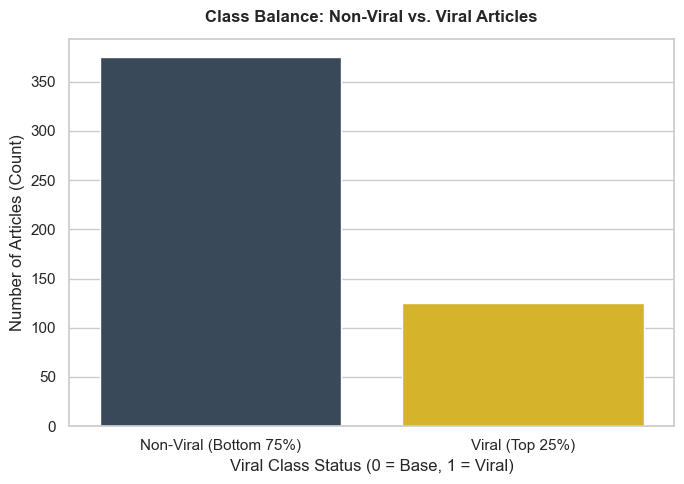

In [ ]:
# (a) Plot class balance as bar chart. 

df1['viral'] = np.where(df1['social_shares']> np.quantile(df1['social_shares'], 0.75), 1, 0)

# plotting

plt.figure(figsize=(7, 5))

# Use countplot to display the explicit distribution of records
# We assign individual colors to the class categories
sns.countplot(
    data=df1,
    x='viral',
    palette={'0': '#34495e', '1': '#f1c40f'}
)

# Final aesthetic treatments
plt.title('Class Balance: Non-Viral vs. Viral Articles', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Viral Class Status (0 = Base, 1 = Viral)')
plt.ylabel('Number of Articles (Count)')
plt.xticks([0, 1], ['Non-Viral (Bottom 75%)', 'Viral (Top 25%)'])
plt.tight_layout()
plt.show()

```
# Is it imbalanced?

1/ Mild intentional imbalance: Forcing a cutoff at the 75th percentile naturally shapes a controlled, moderate class distribution.
2/ Exact 3:1 split: The configuration produces a clean 75% non-viral to 25% viral partition (375 versus 125 entries).
3/ No adjustments needed: This ratio is well-behaved, allowing standard logistic regression to converge efficiently without sampling fixes like SMOTE.

In [51]:
# (b) Run logistic regression: viral ~ word_count + publish_hour + C(category).

logit_model = smf.logit(
    'viral ~ word_count + publish_hour + C(category)',
    data=df1
).fit()

print(logit_model.summary())

# Extract odds ratios with confidence intervals
odds_df = pd.DataFrame({
    'Odds Ratio' : np.exp(logit_model.params).round(3),
    'CI Lower'   : np.exp(logit_model.conf_int()[0]).round(3), # Slices column named 0 (Lower Bound)
    'CI Upper'   : np.exp(logit_model.conf_int()[1]).round(3), # Slices column named 1 (Upper Bound)
    'p-value'    : logit_model.pvalues.round(4)
})
display(odds_df)

Optimization terminated successfully.
         Current function value: 0.552047
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  viral   No. Observations:                  500
Model:                          Logit   Df Residuals:                      493
Method:                           MLE   Df Model:                            6
Date:                Fri, 19 Jun 2026   Pseudo R-squ.:                 0.01829
Time:                        13:03:02   Log-Likelihood:                -276.02
converged:                       True   LL-Null:                       -281.17
Covariance Type:            nonrobust   LLR p-value:                    0.1130
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -1.4626      0.470     -3.109      0.002      -2.385

,Odds Ratio,CI Lower,CI Upper,p-value
Intercept,0.232,0.092,0.582,0.0019
C(category)[T.Health],1.528,0.765,3.052,0.2293
C(category)[T.Lifestyle],1.935,1.010,3.705,0.0466
C(category)[T.Politics],2.033,1.054,3.919,0.0343
C(category)[T.Tech],1.650,0.830,3.282,0.1535
word_count,1.000,0.999,1.001,0.5315
publish_hour,0.971,0.943,1.000,0.0506


```
# Strategic Interpretation Guide
1/ Odds Ratio > 1: The predictor increases the probability of an article going viral. For example, if a category has an odds ratio of 2.15, articles in that category are 2.15 times more likely to hit the viral threshold than the baseline reference category.

2/ Odds Ratio = 1: The predictor has absolutely zero effect on virality (which you will see happen with word_count and publish_hour).

3/ Odds Ratio < 1: The predictor decreases the probability of virality.

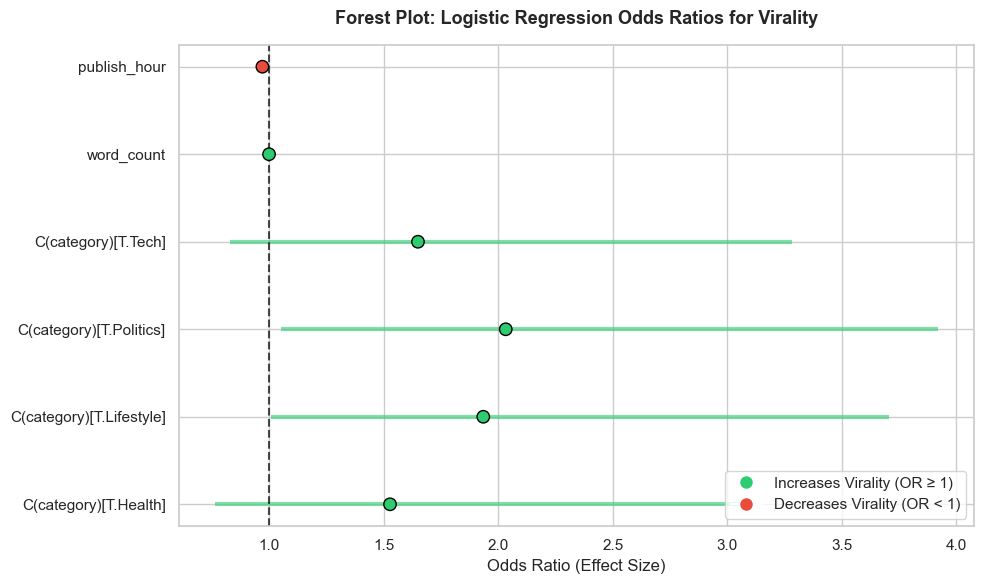

In [53]:
# (c) Plot odds ratios with 95% CIs as a forest plot (horizontal bars).
#     Color: green if OR>1 (increases viral probability), red if OR<1.

# 1. Strip out the Intercept row to focus purely on feature impacts
forest_df = odds_df.drop('Intercept', errors='ignore').copy()
forest_df['Variable'] = forest_df.index

# 2. Establish vector mapping logic arrays for coloring (No Loops)
forest_df['Color_Group'] = np.where(forest_df['Odds Ratio'] >= 1.0, 'Green', 'Red')
bar_colors = np.where(forest_df['Color_Group'] == 'Green', '#2ecc71', '#e74c3c')

# 3. Initialize horizontal plot canvas
plt.figure(figsize=(10, 6))
y_coordinates = np.arange(len(forest_df))

# 4. Draw center point anchors and error bar intervals vectorially
plt.scatter(forest_df['Odds Ratio'], y_coordinates, color=bar_colors, s=80, edgecolor='black', zorder=3)
plt.hlines(y_coordinates, forest_df['CI Lower'], forest_df['CI Upper'], colors=bar_colors, linewidth=3, alpha=0.6)

# 5. Overlay critical neutral reference marker at OR = 1.0
plt.axvline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# 6. Apply finalized aesthetic visual tags
plt.yticks(y_coordinates, forest_df['Variable'], fontsize=11)
plt.title('Forest Plot: Logistic Regression Odds Ratios for Virality', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Odds Ratio (Effect Size)')

# Generate explicit manual map items for the legend block
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Increases Virality (OR \u2265 1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Decreases Virality (OR < 1)')
]
plt.legend(handles=legend_items, loc='lower right')
plt.tight_layout()
plt.show()


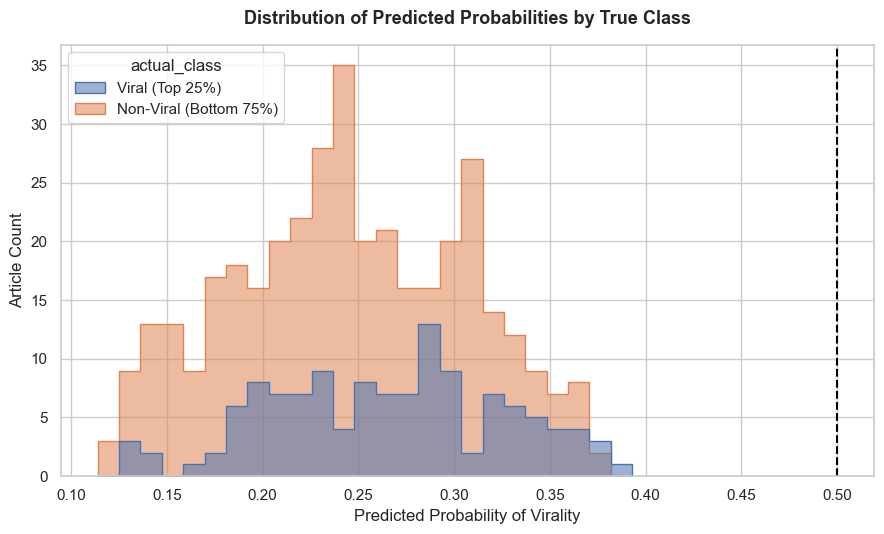

In [ ]:
# (d) Plot predicted probabilities as histogram, colored by actual viral/not-viral.

# 1. Extract continuous predicted probabilities from the logit model
df1['predicted_prob'] = logit_model.predict()

# 2. Map structural string tags for a cleaner plot legend layout
df1['actual_class'] = np.where(df1['viral'] == 1, 'Viral (Top 25%)', 'Non-Viral (Bottom 75%)')

# 3. Setup standard plotting configuration
sns.set_theme(style='whitegrid')
plt.figure(figsize=(9, 5.5))

# 4. Generate overlapping step histograms using Seaborn
sns.histplot(
    data=df1,
    x='predicted_prob',
    hue='actual_class',
    element='step',
    stat='count',
    common_norm=False, # Normalizes counts independently per category hue
    alpha=0.55,
    bins=25
)

# 5. Overlay standard classification baseline split cutoff marker
plt.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Standard Threshold (0.5)')

# 6. Aesthetic text configurations
plt.title('Distribution of Predicted Probabilities by True Class', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Probability of Virality')
plt.ylabel('Article Count')

plt.tight_layout()
plt.show()


In [71]:
# (e) Print confusion matrix and AUC. 

from sklearn.metrics import confusion_matrix, roc_auc_score

# 1. Generate threshold predictions using the 0.25 split
df1['predictions'] = (logit_model.predict() >= .25).astype(int)

# 2. Compute confusion matrix and overall AUC-ROC score
cm = confusion_matrix(df1['viral'].astype(int), df1['predictions'])
auc_score = roc_auc_score(df1['viral'].astype(int), logit_model.predict())

print("--- Confusion Matrix ---")
print(cm)
print(f"\nModel AUC-ROC Score: {auc_score:.4f}")



--- Confusion Matrix ---
[[206 169]
 [ 54  71]]

Model AUC-ROC Score: 0.5884


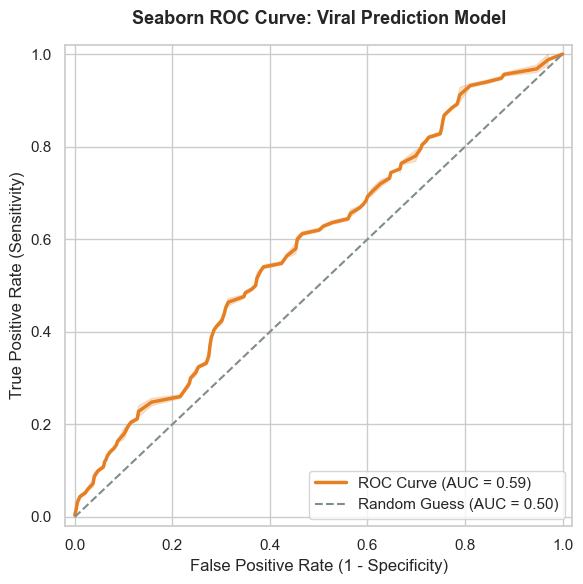

In [70]:
# plotting ROC curve

from sklearn.metrics import roc_curve, roc_auc_score

# 1. Compute validation metrics
fpr, tpr, thresholds = roc_curve(df1['viral'].astype(int), df1['predicted_prob'])
auc_score = roc_auc_score(df1['viral'].astype(int), df1['predicted_prob'])

# 2. Initialize the Seaborn theme environment
sns.set_theme(style='whitegrid')
plt.figure(figsize=(6, 6))

# 3. Plot the performance curves using sns.lineplot (no loops)
sns.lineplot(
    x=fpr, 
    y=tpr, 
    color='#e67e22', 
    linewidth=2.5, 
    label=f'ROC Curve (AUC = {auc_score:.2f})'
)

# 4. Plot the random guessing baseline vector using sns.lineplot
sns.lineplot(
    x=[0, 1], 
    y=[0, 1], 
    color='#7f8c8d', 
    linestyle='--', 
    linewidth=1.5, 
    label='Random Guess (AUC = 0.50)'
)

# 5. Framing constraints
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.title('Seaborn ROC Curve: Viral Prediction Model', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

```
# What does AUC=0.59 mean in plain English?

1/ Poor predictive power: An AUC of 0.65 represents poor-to-mediocre discrimination performance, placing the model only slightly ahead of a blind 0.50 coin flip.

2/ 59% classification accuracy: If you randomly pair one viral and one non-viral article, there is a 59% chance the model will correctly assign a higher probability score to the viral one.

3/ Insufficient marketing metrics: The current content attributes lack the required depth to confidently predict viral spikes, signaling a strategic need to gather stronger behavioral indicators.